In [1]:
# --- [CELL 0]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 1}
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import time
from skimage.io import imshow
from IPython.display import display
from skimage.transform import resize
from tensorflow.keras.layers import Dense, BatchNormalization, LeakyReLU, Reshape
from tensorflow.keras.layers import Conv2DTranspose, Input, Concatenate, Conv2D
from tensorflow.keras.layers import Conv2D, Dropout, Flatten
from tensorflow.keras.models import Model
import os
import glob
from tensorflow.keras.callbacks import LambdaCallback

In [2]:
# --- [CELL 1]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 2}
def Load_Pprepr_Data():
    Data = tf.keras.datasets.cifar10.load_data()
    (train_images , train_labels) , (test_images , test_labels) = Data
    return train_images ,train_labels ,test_images ,test_labels



def create_train_dataset(train_images, train_labels, batch_size):
    """
    Creates a TensorFlow dataset for training the AC-GAN model.

    Args:
        train_images (ndarray): Array of training images.
        train_labels (ndarray): Array of training labels.
        batch_size (int): Number of samples per batch.

    Returns:
        tf.data.Dataset: Training dataset.
    """

    # Calculate the buffer size based on the number of training images
    BUFFER_SIZE = train_images.shape[0]
    
    # Create a dataset for the training labels and map them to one-hot encoded vectors
    train_dataset_y = tf.data.Dataset.from_tensor_slices(train_labels[:, 0]).map(lambda y: tf.one_hot(y, 10))
    
    # Create a dataset for the training images
    train_dataset_x = tf.data.Dataset.from_tensor_slices(train_images)
    
    # Combine the image and label datasets, shuffle, and batch them
    train_dataset = tf.data.Dataset.zip((train_dataset_x, train_dataset_y)).shuffle(BUFFER_SIZE).batch(batch_size)
    
    return train_dataset



def scale_image_to_float(image):
    """
    Scales the pixel values of an image to the range [-1, 1].

    Args:
        image (numpy.ndarray): Input image.

    Returns:
        numpy.ndarray: Image with pixel values scaled to the range [-1, 1].
    """
    return (image.astype(np.float32) - 127.5) / 127.5


def scale_image_to_uint8(image):
    """
    Scales the pixel values of an image to the range [0, 255] and converts them to uint8.

    Args:
        image (numpy.ndarray): Input image.

    Returns:
        numpy.ndarray: Image with pixel values scaled to the range [0, 255] and converted to uint8.
    """
    return np.clip((image * 127.5) + 128, 0, 255).astype(np.uint8)

In [3]:
# --- [CELL 2]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 3}
class AC_GAN:

        
        
    def __init__(self):
        self.generator = None
        self.discriminator = None
        self.generator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
        self.discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
        self.generator_gradients = None
        self.discriminator_gradients = None
        
        self.checkpoint_dir = './checkpoints'
        os.makedirs(self.checkpoint_dir, exist_ok=True)
        self.checkpoint_prefix = os.path.join(self.checkpoint_dir, 'ckpt')

        # Rest of your code...

        
        
        
    def build_generator(self,latent_dim, num_classes):
        """
        Builds the AC-GAN generator model.

        Args:
            latent_dim (int): Dimension of the noise input.
            num_classes (int): Number of classes/labels.

        Returns:
            generator (Model): The AC-GAN generator model.
        """
        # Noise input and label input
        noise_input = Input((latent_dim,))
        label_input = Input((num_classes,))

        # Concatenate noise and label inputs
        x = Concatenate()([noise_input, label_input])

        # Fully connected layer
        x = Dense(4 * 4 * 256, use_bias=False)(x)
        x = BatchNormalization()(x)
        x = LeakyReLU()(x)

        # Reshape to 4x4x256 feature maps
        x = Reshape((4, 4, 256))(x)

        # Transposed convolutional layers
        x = Conv2DTranspose(128, (4, 4), strides=(2, 2), padding='same', use_bias=False)(x)
        x = BatchNormalization()(x)
        x = LeakyReLU()(x)

        x = Conv2DTranspose(64, (4, 4), strides=(2, 2), padding='same', use_bias=False)(x)
        x = BatchNormalization()(x)
        x = LeakyReLU()(x)

        x = Conv2DTranspose(32, (4, 4), strides=(2, 2), padding='same', use_bias=False)(x)
        x = BatchNormalization()(x)
        x = LeakyReLU()(x)

        # Output layer with tanh activation
        output = Conv2D(3, (3, 3), strides=(1, 1), padding='same', activation='tanh')(x)

        # Create the generator model
        generator = Model(inputs=[noise_input, label_input], outputs=output)

        return generator
    
    
    
    
    
    def build_discriminator(self,input_shape):
        """
        Build a discriminator model with the given input shape.

        Parameters:
            input_shape (tuple): Shape of the input images (height, width, channels).

        Returns:
            discriminator (Model): Discriminator model.

        """
        _i = Input(input_shape)
        _ = Conv2D(64, (3, 3), strides=(2, 2), padding='same')(_i)
        _ = LeakyReLU()(_)  # Apply LeakyReLU activation
        _ = Conv2D(128, (3, 3), strides=(2, 2), padding='same', use_bias=False)(_)
        _ = BatchNormalization()(_)  # Apply batch normalization
        _ = LeakyReLU()(_)  # Apply LeakyReLU activation
        _ = Conv2D(128, (3, 3), strides=(2, 2), padding='same', use_bias=False)(_)
        _ = BatchNormalization()(_)  # Apply batch normalization
        _ = LeakyReLU()(_)  # Apply LeakyReLU activation
        _ = Conv2D(128, (3, 3), strides=(2, 2), padding='same', use_bias=False)(_)
        _ = BatchNormalization()(_)  # Apply batch normalization
        _ = LeakyReLU()(_)  # Apply LeakyReLU activation
        _ = Flatten()(_)
        _0 = Dense(1)(_)  # Output for real/fake prediction
        _1 = Dense(10)(_)  # Output for class prediction

        discriminator = Model(inputs=_i, outputs=[_0, _1])
        return discriminator
    
    def prepare_generation(self,num_generated_examples, latent_dim):
        """
        Prepare vectors for image generation.

        Args:
            num_epochs (int): Number of training epochs.
            num_generated_examples (int): Number of images to generate.
            latent_dim (int): Dimension of the latent space vector.

        Returns:
            random_vector_for_generation (tf.Tensor): Random vector for generating images.
            condition_vector_generation (tf.Tensor): Condition vector for generating images.
        """
        # Generate random vector for image generation
        random_vector_for_generation = tf.random.normal([num_generated_examples, latent_dim])
        condition_vector_generation = tf.one_hot(list(range(10)) * 2, 10)


        return random_vector_for_generation, condition_vector_generation
    
    
    
    def compute_compute_generator_loss(self,generated_output, labels):
        """
        Computes the generator loss for adversarial and class label matching.

        Args:
            generated_output (tuple): Tuple containing the discriminator output and class predictions.
            labels (tf.Tensor): True class labels.

        Returns:
            tf.Tensor: Total generator loss.

        """
        out_d, out_c = generated_output

        # Calculate the loss component for fooling the discriminator
        loss_discrit = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(
            labels=tf.ones_like(out_d), logits=out_d))

        # Calculate the loss component for matching the desired classes
        loss_create = tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits(
            labels=labels, logits=out_c))

        # Return the sum of the two loss components
        whole_loss = loss_discrit + loss_create
        return whole_loss





    def compute_compute_discriminator_loss(self,real_discriminator_output, generated_discriminator_output, true_labels):
        """
        Computes the discriminator loss for real and generated examples.

        Args:
            real_discriminator_output (tuple): Tuple containing the discriminator output and class predictions for real examples.
            generated_discriminator_output (tuple): Tuple containing the discriminator output and class predictions for generated examples.
            true_labels (tf.Tensor): True class labels.

        Returns:
            tf.Tensor: Total discriminator loss.

        """
        real_output_d, real_output_c = real_discriminator_output

        # Loss for real examples
        real_loss_d = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(
            labels=tf.ones_like(real_output_d), logits=real_output_d))
        real_loss_c = tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits(
            labels=true_labels, logits=real_output_c))
        modified_real_loss = real_loss_d + real_loss_c

        generated_output_d, generated_output_c = generated_discriminator_output

        # Loss for generated examples
        modified_generated_loss = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(
            labels=tf.zeros_like(generated_output_d), logits=generated_output_d))

        # Total loss
        modified_total_loss = modified_real_loss + modified_generated_loss

        return modified_total_loss
    
    
    
    
    def train_model(self,input_images, input_labels,latent_dim,BATCH_SIZE):
        """
        Performs a single training step for the generator and discriminator models.

        Args:
            input_images (tf.Tensor): Batch of real images.
            input_labels (tf.Tensor): Batch of labels for the images.

        Returns:
            None
        """

        # Generate random noise
#         noise = tf.random.normal([25, latent_dim])
        noise = tf.random.normal([BATCH_SIZE, latent_dim])
#         print('ss')
#         print(np.array(noise.shape))
        # Generate random noise
#         noise = np.random.normal(size=[20, latent_dim])


        with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
            # Generate fake images
            generated_images = self.generator([noise, input_labels], training=True)

            # Get discriminator outputs for real and generated images
            real_outputs = self.discriminator(input_images, training=True)
            generated_outputs = self.discriminator(generated_images, training=True)

            # Compute generator and discriminator losses
            generator_loss = self.compute_compute_generator_loss(generated_outputs, input_labels)
            discriminator_loss = self.compute_compute_discriminator_loss(real_outputs, generated_outputs, input_labels)

        # Compute gradients for generator and discriminator
        self.generator_gradients = gen_tape.gradient(generator_loss, self.generator.trainable_variables)
        self.discriminator_gradients = disc_tape.gradient(discriminator_loss,self.discriminator.trainable_variables)

        # Update generator and discriminator weights
        self.generator_optimizer.apply_gradients(zip(self.generator_gradients, self.generator.trainable_variables))
        self.discriminator_optimizer.apply_gradients(zip(self.discriminator_gradients, self.discriminator.trainable_variables))



    def plot_images(self,images,epoch):

        
        np.save("all_images.npy", np.array(images))
        print(f' generated images of epoch {epoch} , saved to all_images.npy')
        # Create a figure and axes for the subplots with larger figsize
        fig, axes = plt.subplots(nrows=2, ncols=10, figsize=(40, 20))

        # Flatten the axes array to simplify indexing
        axes = axes.flatten()

        # Iterate through the images and plot them in the subplots
        for i in range(20):
            axes[i].imshow(images[i])
            axes[i].axis('off')


        # Add a title to the entire subplot grid
        fig.suptitle(f'Generated images of epoch :{epoch}', fontsize=42)

        # Adjust the spacing between subplots
        plt.tight_layout()

        # Display the plot
        plt.show()

    def save_weights(self, checkpoint_name):
        # Delete older weights
        old_weights = glob.glob(f"{self.checkpoint_prefix}*")
        for weight_file in old_weights:
            os.remove(weight_file)

        # Save the current weights
        self.generator.save_weights(f"{self.checkpoint_prefix}_generator_{checkpoint_name}.weights.h5")
        self.discriminator.save_weights(f"{self.checkpoint_prefix}_discriminator_{checkpoint_name}.weights.h5")


        

        
        
        

    def train(self, train_dataset, latent_dim, num_class, num_examples_to_generate, epochs, batch_size=25):
        self.generator = self.build_generator(latent_dim, num_class)
        self.discriminator = self.build_discriminator((32, 32, 3))

        random_vector_for_generation, condition_vector_generation = self.prepare_generation(num_examples_to_generate,
                                                                                           latent_dim)
        generated = []

        for epoch in range(epochs):
            # Record the start time of the epoch
            start_time = time.time()

            # Iterate over the training dataset
            for images, labels in train_dataset:
                # Perform a single training step for the generator and discriminator models
                self.train_model(images, labels, latent_dim, batch_size)

            # fix extra errors for reproducing and fixing purposes--- noise should be tensor
            # Generate random noise
#             noise = np.random.normal(size=[num_examples_to_generate, latent_dim])
#             print(noise.shape)
            noise = tf.random.normal([num_examples_to_generate, latent_dim])

            # Generate fake images using the generator model
            generated_image = self.generator([noise, condition_vector_generation], training=False)
            print(np.array(generated_image).shape)

            self.plot_images(generated_image, epoch)
            generated.append(generated_image)

            # Print the epoch number and the time taken for the epoch
            print(epoch, time.time() - start_time)

            self.save_weights(f"epoch_{epoch}")

        return np.array(generated)

In [4]:
# --- [CELL 3]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 4}
train_images ,train_labels ,test_images ,test_labels = Load_Pprepr_Data()
train_img_f32 = scale_image_to_float(train_images)
train_dataset = create_train_dataset(train_img_f32, train_labels, 25)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


start
False
False
no wieght found
(20, 32, 32, 3)
 generated images of epoch 0 , saved to all_images.npy


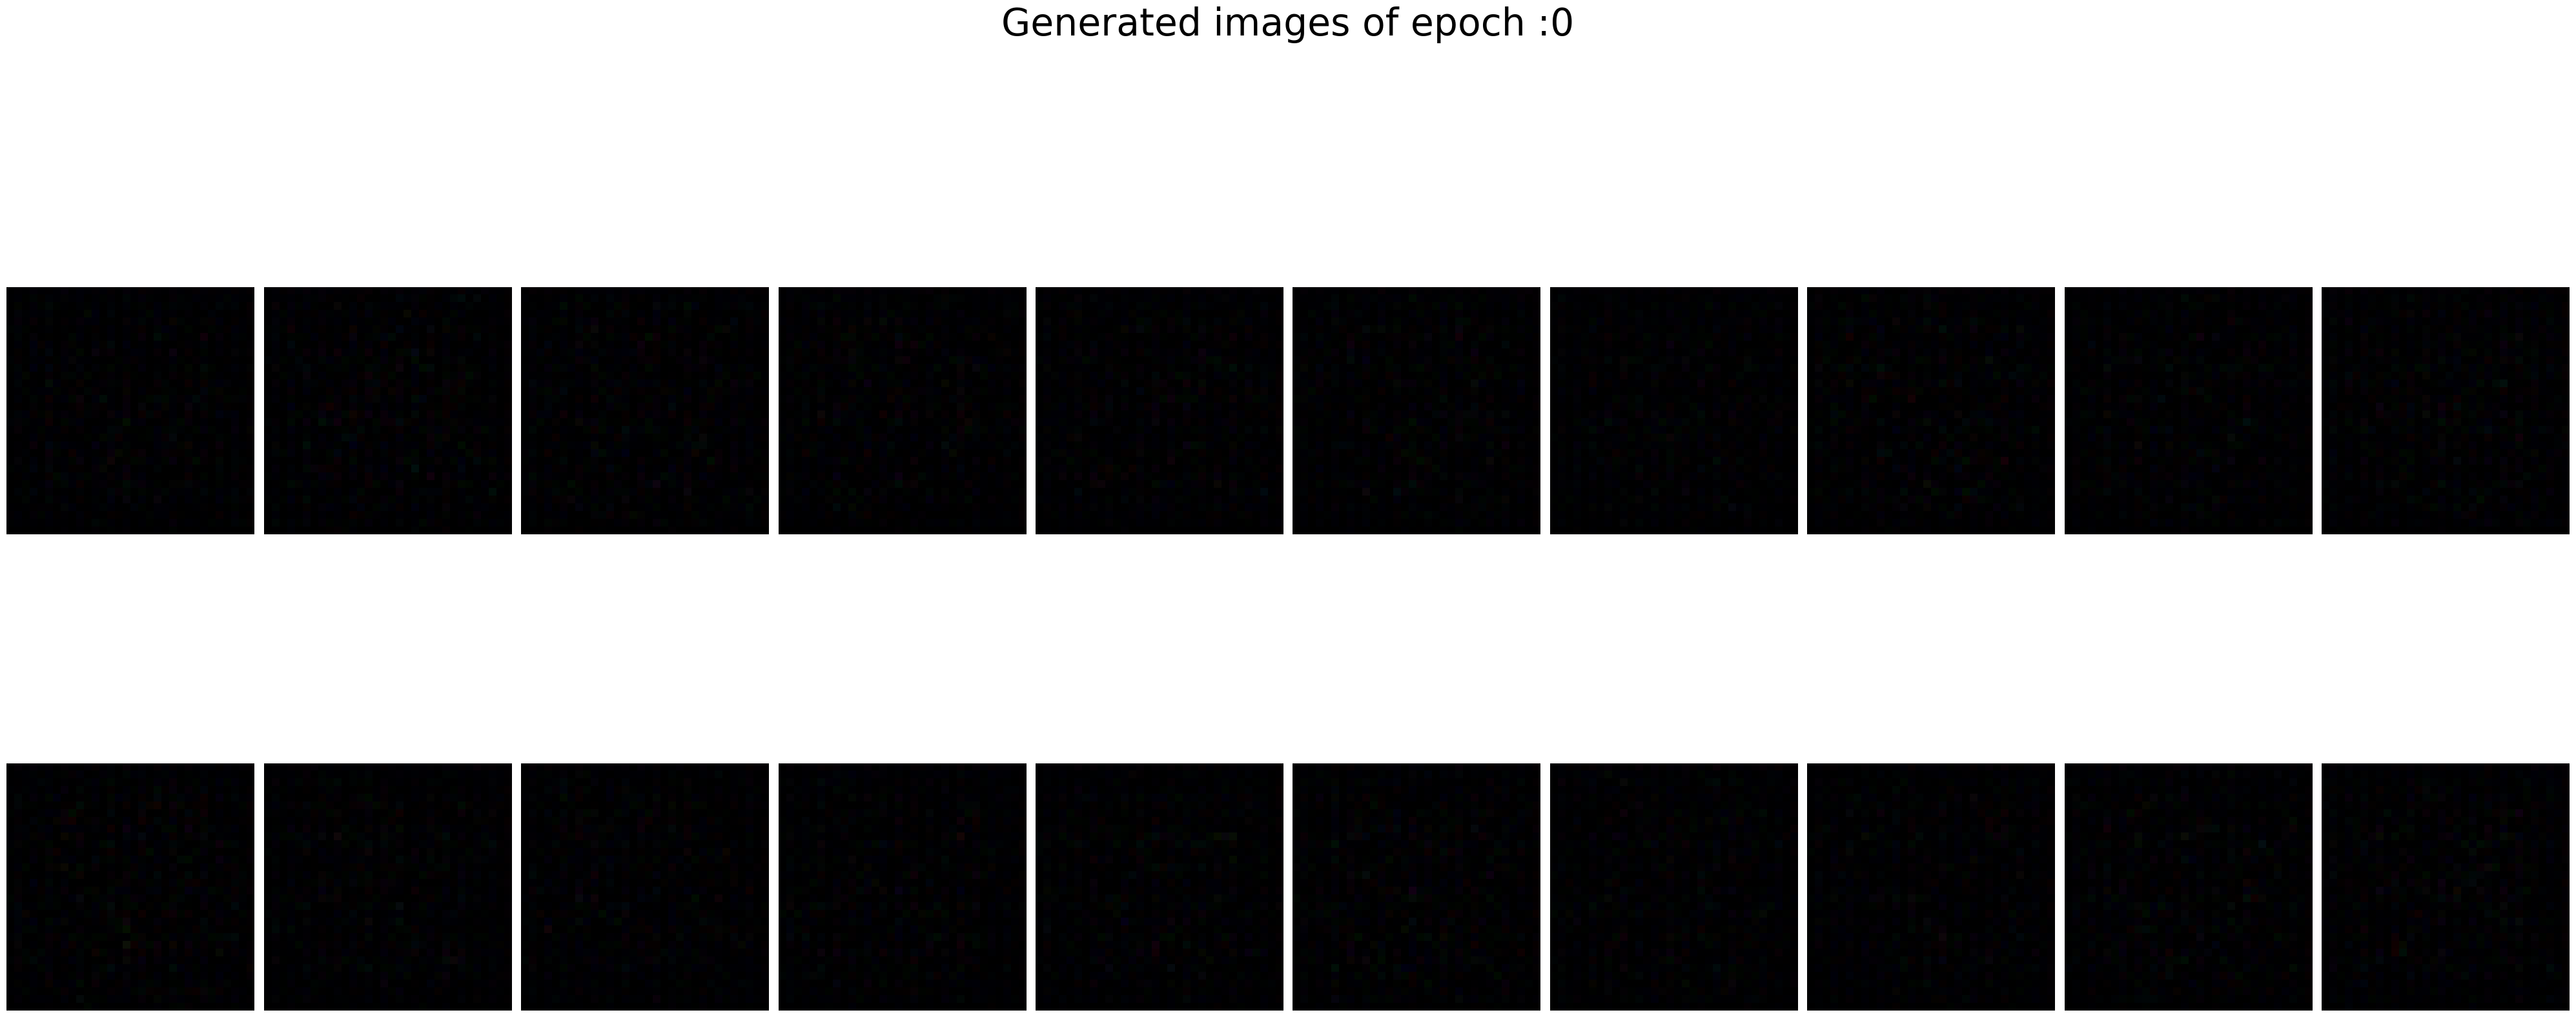

0 6.106167316436768


In [5]:
# --- [CELL 4]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 5}
train_dataset_small = train_dataset.take(16)  # for fast reproducing and fixing purposes


print('start')
acgn = AC_GAN()

# Checkpoint directory
checkpoint_dir = 'checkpoints'

# Check generator and discriminator weights files
generator_weights_file = os.path.join(checkpoint_dir, 'ckpt_generator_epoch_2')
discriminator_weights_file = os.path.join(checkpoint_dir, 'ckpt_discriminator_epoch_2')

# Check if the files exist
generator_files_exist = os.path.exists(generator_weights_file + '.data-00000-of-00001') and \
                        os.path.exists(generator_weights_file + '.index')
discriminator_files_exist = os.path.exists(discriminator_weights_file + '.data-00000-of-00001') and \
                            os.path.exists(discriminator_weights_file + '.index')




print(generator_files_exist)
print(discriminator_files_exist)
if(generator_files_exist and discriminator_files_exist):
    acgn.generator = acgn.build_generator(100, 10)  # Instantiate the generator
    acgn.discriminator = acgn.build_discriminator((32, 32, 3))
    acgn.generator.load_weights(generator_weights_file)
    acgn.discriminator.load_weights(discriminator_weights_file)
    images = acgn.train(train_dataset_small,100,10,20,1,25) # for fast reproducing and fixing purposes
else:
    print('no wieght found')
    images = acgn.train(train_dataset_small,100,10,20,1,25) # for fast reproducing and fixing purposes

In [6]:
# --- [CELL 5]: ---
# cell_state: edited
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 6}
# === BEFORE (original) ===
# np.savetxt('images.txt', images, delimiter=',', fmt='%d')

# === AFTER (edited) ===
np.save('images.npy', images)

In [7]:
import os
import numpy as np

assert os.path.exists('images.npy'), "File should exist"
arr = np.load('images.npy')

# The 'images' variable is 5D: (epochs, batch, height, width, channels)
assert arr.ndim == 5, f"Expected 5D array, got {arr.ndim}D - patch may have lost dimensionality"
assert arr.size > 0, "Array should contain data"
assert arr.dtype == np.float32 or arr.dtype == np.float64, "Should be numeric type"